install important libreries 

In [1]:
pip install matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [9]:
url = "https://epoch.ai/data/notable_ai_models.csv"   # or all_ai_models.csv
df = pd.read_csv(url)

print(df.shape)
print(df.columns.tolist())
df[["Model", "Publication date", "Domain", "Parameters"]].head()

(1078, 47)
['Model', 'Organization', 'Publication date', 'Domain', 'Task', 'Parameters', 'Parameters notes', 'Training compute (FLOP)', 'Training compute notes', 'Training dataset', 'Training dataset size (total)', 'Dataset size notes', 'Confidence', 'Link', 'Reference', 'Citations', 'Authors', 'Abstract', 'Organization categorization', 'Country (of organization)', 'Notability criteria', 'Notability criteria notes', 'Epochs', 'Training time (hours)', 'Training time notes', 'Training hardware', 'Hardware quantity', 'Hardware utilization (MFU)', 'Training compute cost (2023 USD)', 'Compute cost notes', 'Training power draw (W)', 'Base model', 'Finetune compute (FLOP)', 'Finetune compute notes', 'Batch size', 'Batch size notes', 'Model accessibility', 'Training code accessibility', 'Inference code accessibility', 'Accessibility notes', 'Numerical format', 'Frontier model', 'Hardware acquisition cost', 'Hardware utilization (HFU)', 'Training compute cost (cloud)', 'Training compute cost (u

,Model,Publication date,Domain,Parameters
0,Gemini 4 Argon,2026-09-30,"Language,Multimodal,Vision",NaN
1,GPT-6.1 Sol,2026-09-29,"Multimodal,Language,Vision",NaN
2,Claude Sonnet 5.5,2026-09-28,"Language,Multimodal,Vision",NaN
3,GPT-6 Sol,2026-09-22,"Multimodal,Language,Vision",NaN
4,GPT-6 Luna,2026-09-22,"Multimodal,Language,Vision",NaN


category
Language            406
Vision              153
Other               139
Image generation     26
Name: count, dtype: int64


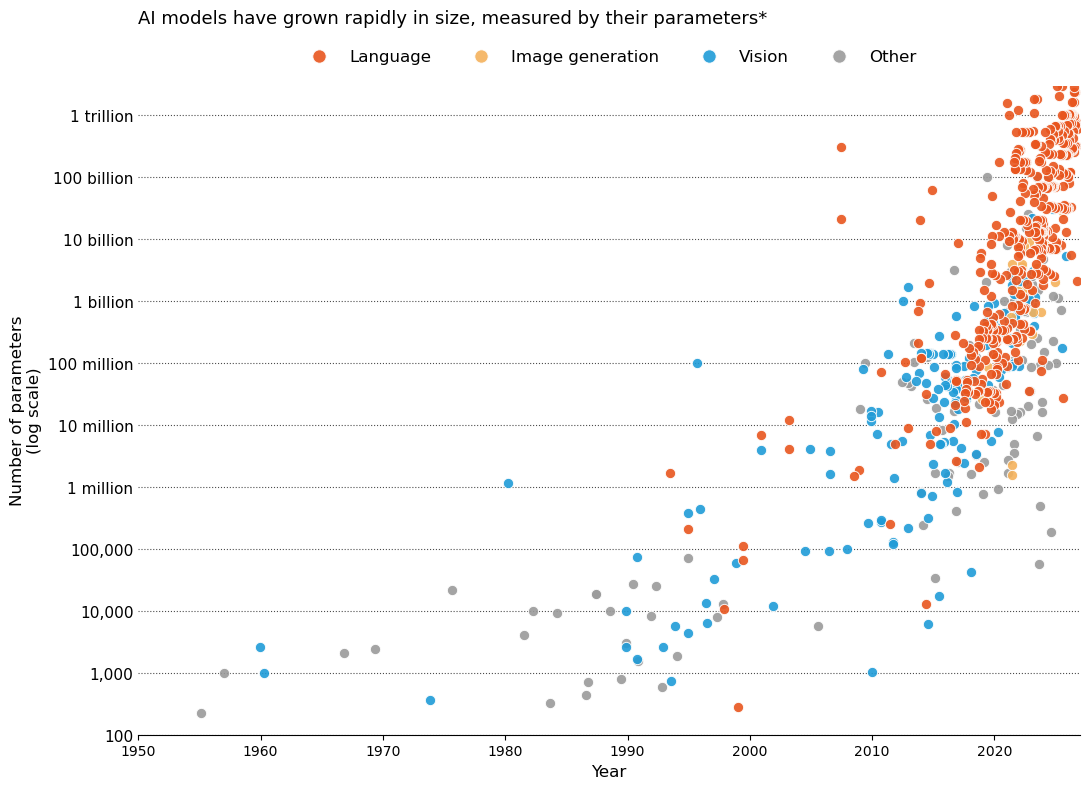

In [11]:
df = df[["Model", "Publication date", "Domain", "Parameters"]].copy()

# Keep only rows that have a parameter count and a date
df = df.dropna(subset=["Parameters", "Publication date", "Domain"])
df["Parameters"] = pd.to_numeric(df["Parameters"], errors="coerce")
df = df[df["Parameters"] > 0]

# Convert date to a decimal year (e.g. 2022.5)
df["Publication date"] = pd.to_datetime(df["Publication date"], errors="coerce")
df = df.dropna(subset=["Publication date"])
df["year"] = df["Publication date"].dt.year + (df["Publication date"].dt.dayofyear / 365.25)

# Map Epoch's Domain values to the 4 categories in your image
def map_domain(d):
    d = str(d).lower()
    if "language" in d:
        return "Language"
    if "image generation" in d or "drawing" in d:
        return "Image generation"
    if "vision" in d:
        return "Vision"
    return "Other"

df["category"] = df["Domain"].apply(map_domain)
print(df["category"].value_counts())

colors = {
    "Language":         "#E8551E",  # dark orange
    "Image generation": "#F4B25C",  # light orange
    "Vision":           "#1F9BD7",  # blue
    "Other":            "#9A9A9A",  # grey
}

# Draw "Other" first so the colored points sit on top
order = ["Other", "Vision", "Image generation", "Language"]

fig, ax = plt.subplots(figsize=(11, 8))

for cat in order:
    sub = df[df["category"] == cat]
    ax.scatter(sub["year"], sub["Parameters"],
               s=55, color=colors[cat], edgecolor="white",
               linewidth=0.7, alpha=0.9, label=cat, zorder=3)

ax.set_yscale("log")
ax.set_ylim(100, 3e12)

ticks  = [100, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12]
labels = ["100", "1,000", "10,000", "100,000", "1 million", "10 million",
          "100 million", "1 billion", "10 billion", "100 billion", "1 trillion"]
ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=11)
ax.minorticks_off()

ax.grid(axis="y", linestyle=":", color="black", alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)

ax.set_ylabel("Number of parameters\n(log scale)", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_xlim(1950, 2027)

# Legend order matches the image
handles, lbls = ax.get_legend_handles_labels()
want = ["Language", "Image generation", "Vision", "Other"]
ordered = [handles[lbls.index(w)] for w in want if w in lbls]
ax.legend(ordered, want, loc="upper center", bbox_to_anchor=(0.5, 1.08),
          ncol=4, frameon=False, fontsize=12, markerscale=1.3)

ax.set_title("AI models have grown rapidly in size, measured by their parameters*",
             fontsize=13, pad=45, loc="left")

plt.tight_layout()
plt.show()

In [14]:
fig.savefig("ai_model_parameters_real.png", dpi=300, bbox_inches="tight")